## Application 3: power analysis figures

In [ ]:
from pathlib import Path
import sys

# --- Resolve repo root (works whether you run from repo root or within notebooks/) ---
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    if (REPO_ROOT.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent
    elif (REPO_ROOT.parent.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

from IPython.display import display
from notebooks.set_up import (
    ensure_dirs,
    FIG_DIR,
    STUDY_DESIGN_DIR,
)

ensure_dirs()

# Inputs
output_result = str(STUDY_DESIGN_DIR) + "/"

# Outputs
output_figure = FIG_DIR / "study_design"

# For legacy code that uses string concatenation:
output_figure = str(output_figure) + "/"


# Create plots for Application 3

n,power,mean_cvd_rank,mean_cvd_importance,reps
200,0.13,15.0,0.0,100
500,0.54,15.0,0.0,100
1000,0.67,15.0,0.0,100
2000,0.94,8.28,0.0120691974886586,100
5000,1.0,1.0,0.5764642794208611,100


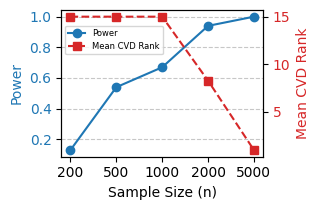

In [0]:
# plot power curve against sample size
# plot the average variable-importance rank curve for CVD against sample size
## import the summary data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

power_results = pd.read_csv(output_result + "power_by_n_allcov.csv")
display(power_results)

# plot two curves with different y axes in the same figure
n_values = power_results["n"].astype(int)
power = power_results["power"]
mean_cvd_rank = power_results["mean_cvd_rank"]

fig, ax1 = plt.subplots(figsize=(3.3, 2.2))

color1 = "#1f77b4"
color2 = "#d62728"

# Ensure equal spacing for n values on x-axis
x = np.arange(len(n_values))

ax1.plot(x, power, 'o-', color=color1, label="Power")
ax1.set_xlabel("Sample Size (n)")
ax1.set_ylabel("Power", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(n_values)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(x, mean_cvd_rank, 's--', color=color2, label="Mean CVD Rank")
ax2.set_ylabel("Mean CVD Rank", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc="upper left", bbox_to_anchor=(0.20, 0.88), fontsize=6)

plt.tight_layout()
plt.savefig(output_figure + "power_rank_n.pdf", format="pdf", bbox_inches="tight")
plt.show()